<a href="https://colab.research.google.com/github/mhasan502/Age_Estimation/blob/Jibon/Age.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notes

**Process:**
1. Prepare the Data.
2. Define the Model.
3. Train the Model.
4. Evaluate the Model.
5. Make Predictions.

**Backpropagation:**
1. Forward Pass: Compute Loss.
2. Compute local gradients.
3. Backward Pass: Compute dLoss / dWeight using Chain Rule.

**Training Pipeline:**
0. Prepare Dataset
1. Design Model: Input size, Output size, forward pass.
2. Construct Loss and Optimizer.
3. Training Loop: 
     - Forward Pass: Compute Prediction
     - Backward Pass: Gradient 
     - Update Weights.

**To improve performance:**
Focusing on the dataset itself

1. Improving generalization performance
2. Avoiding overfitting with (1) more data and (2) data
augmentation
3. Reducing network capacity & early stopping
4. Adding norm penalties to the loss: L1 & L2 regularization
5. Dropout



---



# Installing Required Packages

In [ ]:
### --- For Connecting Google Colab with Local Host --- ###
# pip install jupyter_http_over_ws
## jupyter serverextension enable --py jupyter_http_over_ws
## jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0

### --- For Progress Bar --- ###
#pip install tqdm

#pip install opencv-python
#pip install albumentations

# Importing Required Packages

In [ ]:
import os
import sys
import numpy as np
from PIL import Image
from tqdm import tqdm
from parse import parse
from autocrop import Cropper
from IPython.display import clear_output

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Scale, Grayscale, Resize, transforms

import cv2
import albumentations as A

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

#import warnings
#warnings.filterwarnings("ignore")

# device = torch.device("cpu")
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [ ]:
torch.backends.cudnn.benchmark = True

In [ ]:
torch.cuda.device_count()

1

In [ ]:
!nvidia-smi -L 

GPU 0: NVIDIA GeForce 920MX (UUID: GPU-38bea3f0-6644-d822-3fce-ca69b5e03f7d)


In [ ]:
cuda_sum = torch.cuda.memory_summary(torch.device("cuda"), abbreviated=False)
print(cuda_sum)

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |       0 B  |       0 B  |       0 B  |       0 B  |
|       from large pool |       0 B  |       0 B  |       0 B  |       0 B  |
|       from small pool |       0 B  |       0 B  |       0 B  |       0 B  |
|---------------------------------------------------------------------------|
| Active memory         |       0 B  |       0 B  |       0 B  |       0 B  |
|       from large pool |       0 B  |       0 B  |       0 B  |

In [ ]:
#torch.cuda.empty_cache()



---



# Hyperparameters Setting

In [ ]:
### --- Hyperparameters --- ###

input_size = 64                                      # 64x64
num_channels = 3
hidden_units = 32                                    # 
num_classes = 117                                    # total possible outputs
learning_rate = 0.01                                # 
num_epochs = 10                                      # epoch = 1-forward and backward pass of ALL training samples
batch_size = 64                                      # batch_size = number of training samples in one forward & backward pass
#step_size = 10                                      # number of iterations = number of passes, each pass using [batch_size] number of samples
                                                     # e.g. 100 samples, batch_size=20 --> 100/20 = 5 iterations for 1 epoch

# 1. Data Preparation

## a. Transformation

In [ ]:
#def get_mean_and_std(loader):
#  mean = 0
#  std = 0
#  total_images_count = 0
#
#  for images, _ in loader :
#    image_count_in_a_batch = images.size(0)
#    images = images.view(image_count_in_a_batch, images.size(1), -1)
#    mean +=  images.mean(2).sum(0)
#    std += images.std(2).sum (0)
#    total_images_count += image_court_in_a_batch
#
#  mean /= total_images_count
#  std /= total_images_count
#
#  return mean, std

#mean, standard_deviation = get_mean_and_std(train_loader)

In [ ]:
### --- Data Transformation --- ###

transformT = transforms.Compose([transforms.Resize((input_size, input_size)),
                                Grayscale(num_channels),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(10),
                                transforms.ToTensor(),
                                transforms.Normalize(mean =[0.0, 0.0, 0.0], std = [1.0, 1.0, 1.0] ) # = (value - mean) / std
])

In [ ]:
### --- Data Transformation using Albumentations as A --- ###

transformA = A.Compose([A.Resize(input_size, input_size),
                       A.ToGray(p=1),
                       A.Rotate(limit=10, p=0.3),
                       A.HorizontalFlip(p=0.4),
                       A.OpticalDistortion(p=0.2),
                       A.OneOf([A.Blur(blur_limit=3, p=0.2),
                                A.ColorJitter(p=0.2),                                
                       ], p=0.2)
])

In [ ]:
def visualize(image):
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    plt.imshow(image)

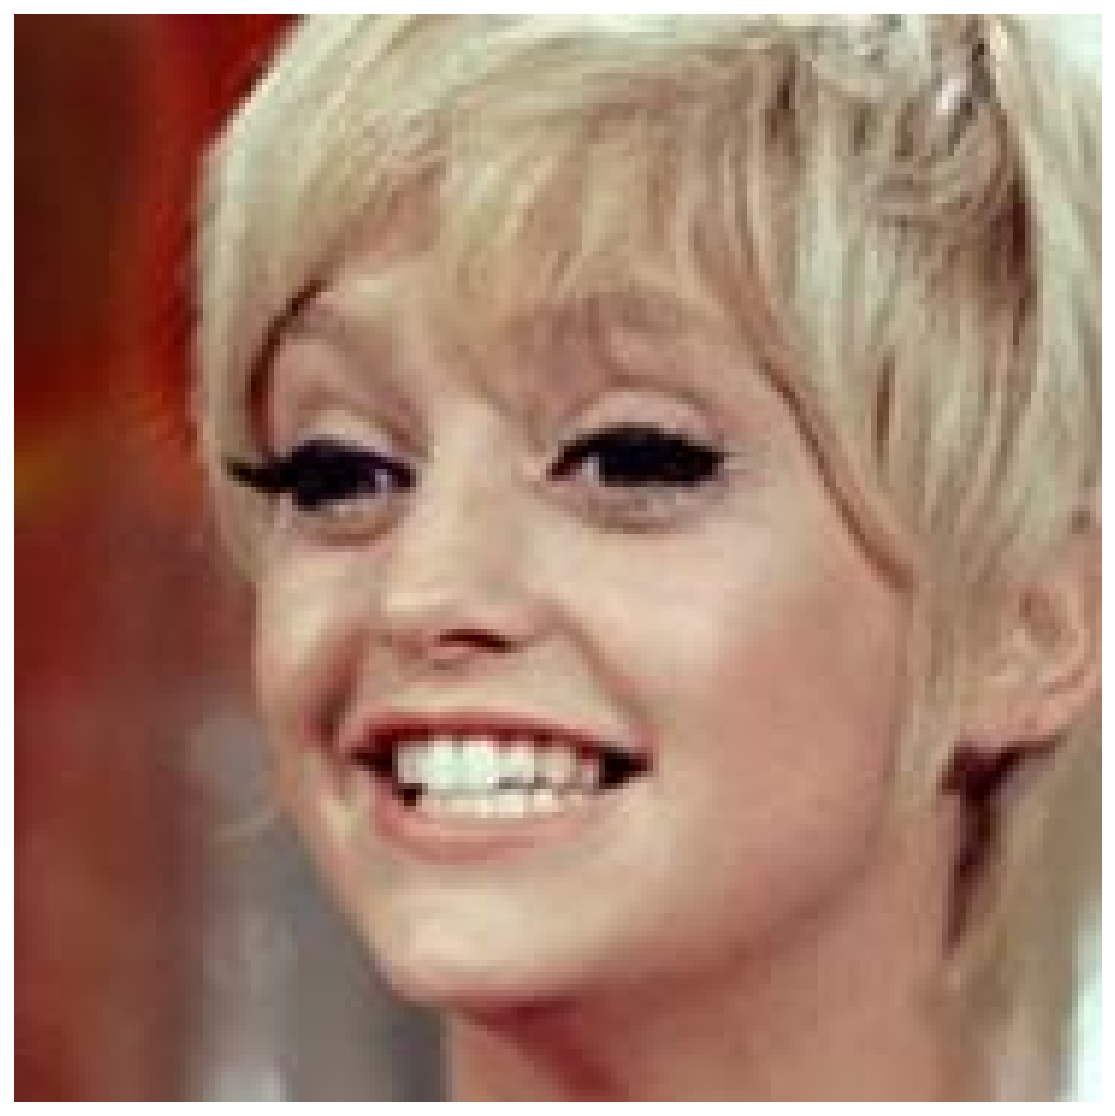

In [ ]:
image = Image.open('AgeDB/10001_GoldieHawn_23_f.jpg')
visualize(image)

In [ ]:
image_list = [image]
cropper = Cropper()

try: 
  #Get a Numpy array of the cropped image
  cropped_array = cropper.crop(image)
  #Save the cropped image with PIL
  image = Image.fromarray(cropped_array)
  
except:
  pass

image = np.array(image)
for i in range(5):
  augmented_images = transformA(image=image)['image']
  image_list.append(augmented_images)


0
1
2
3
4
5


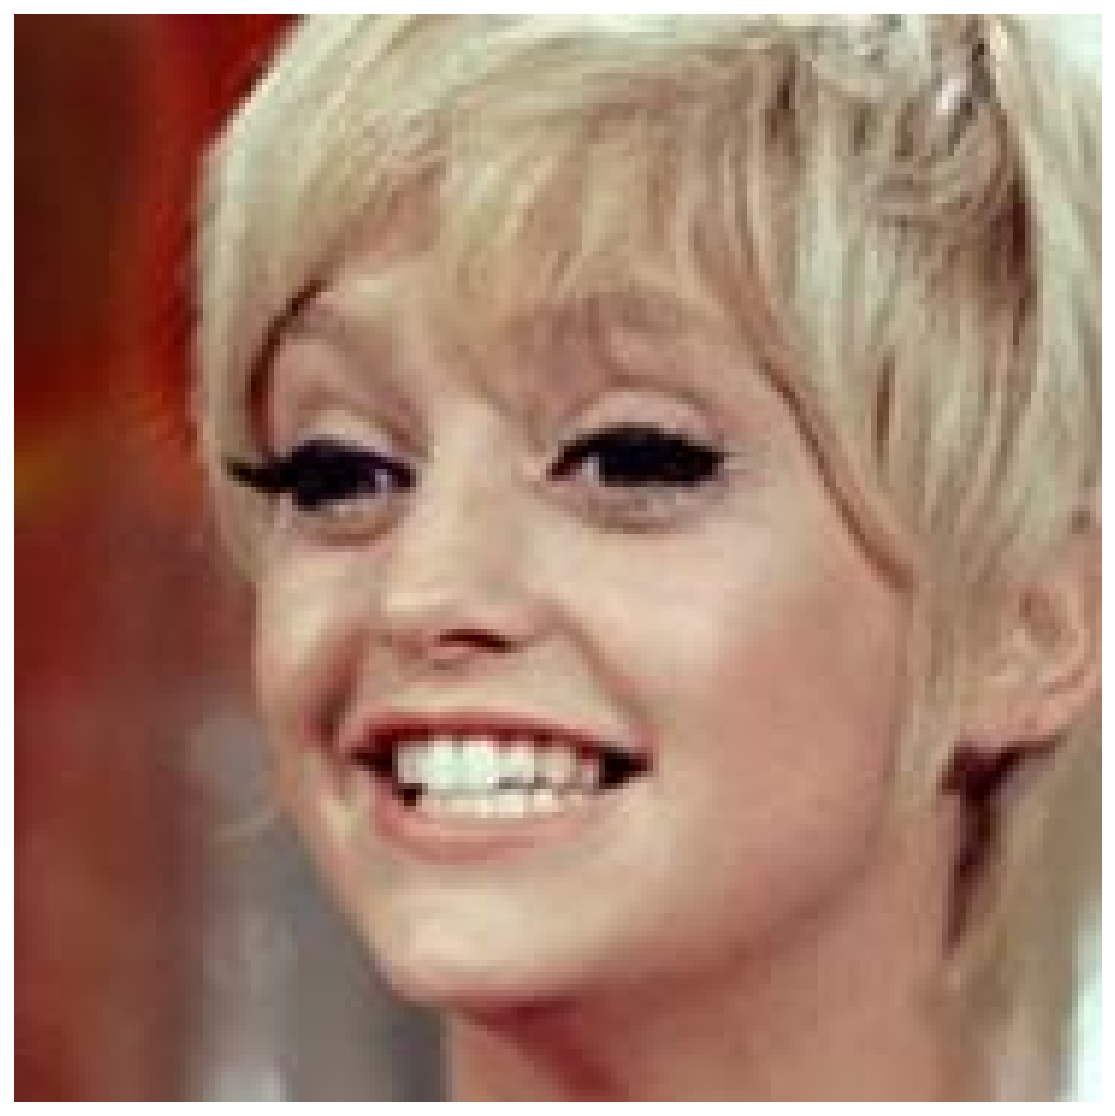

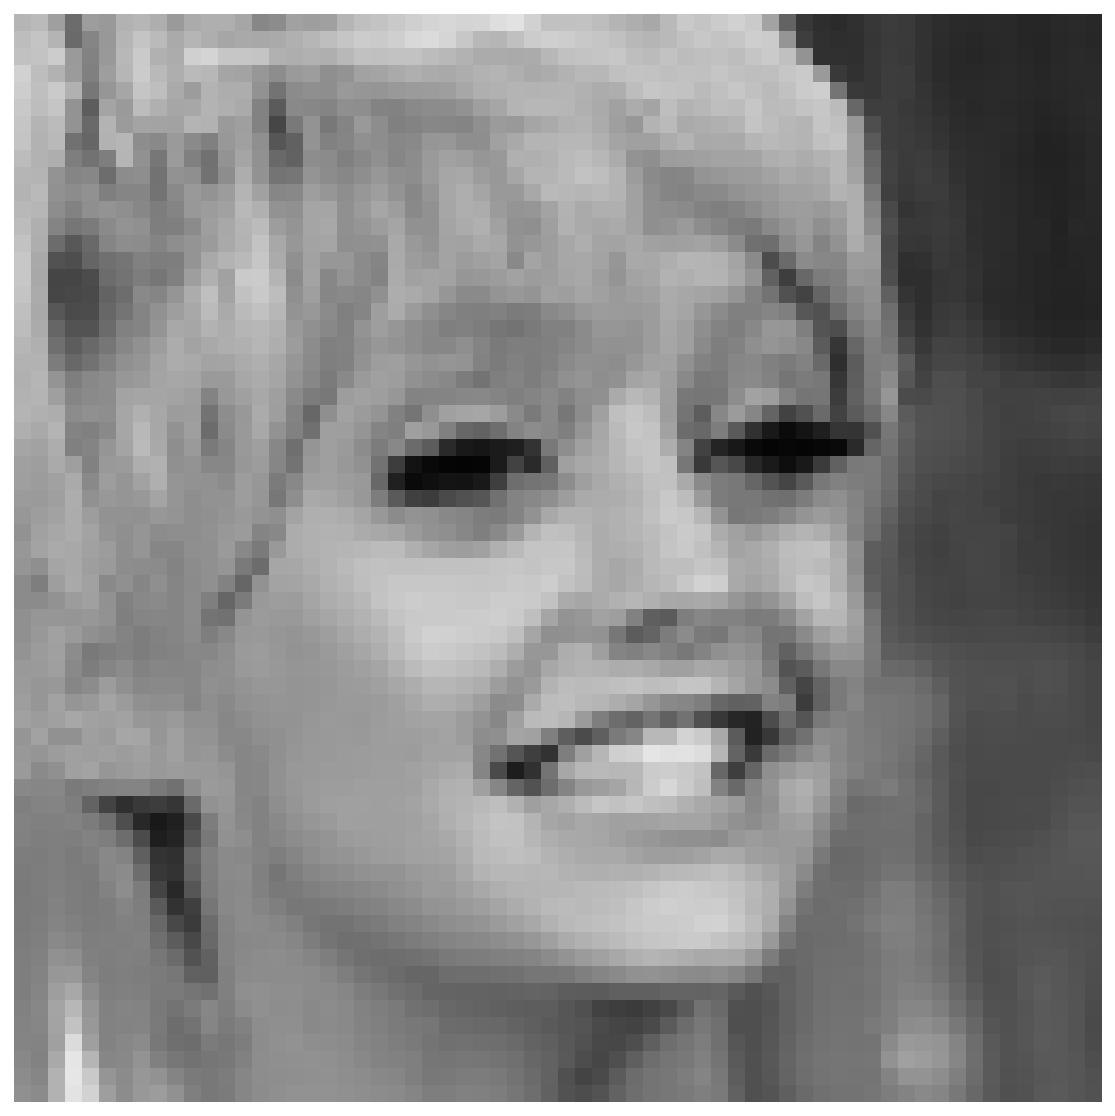

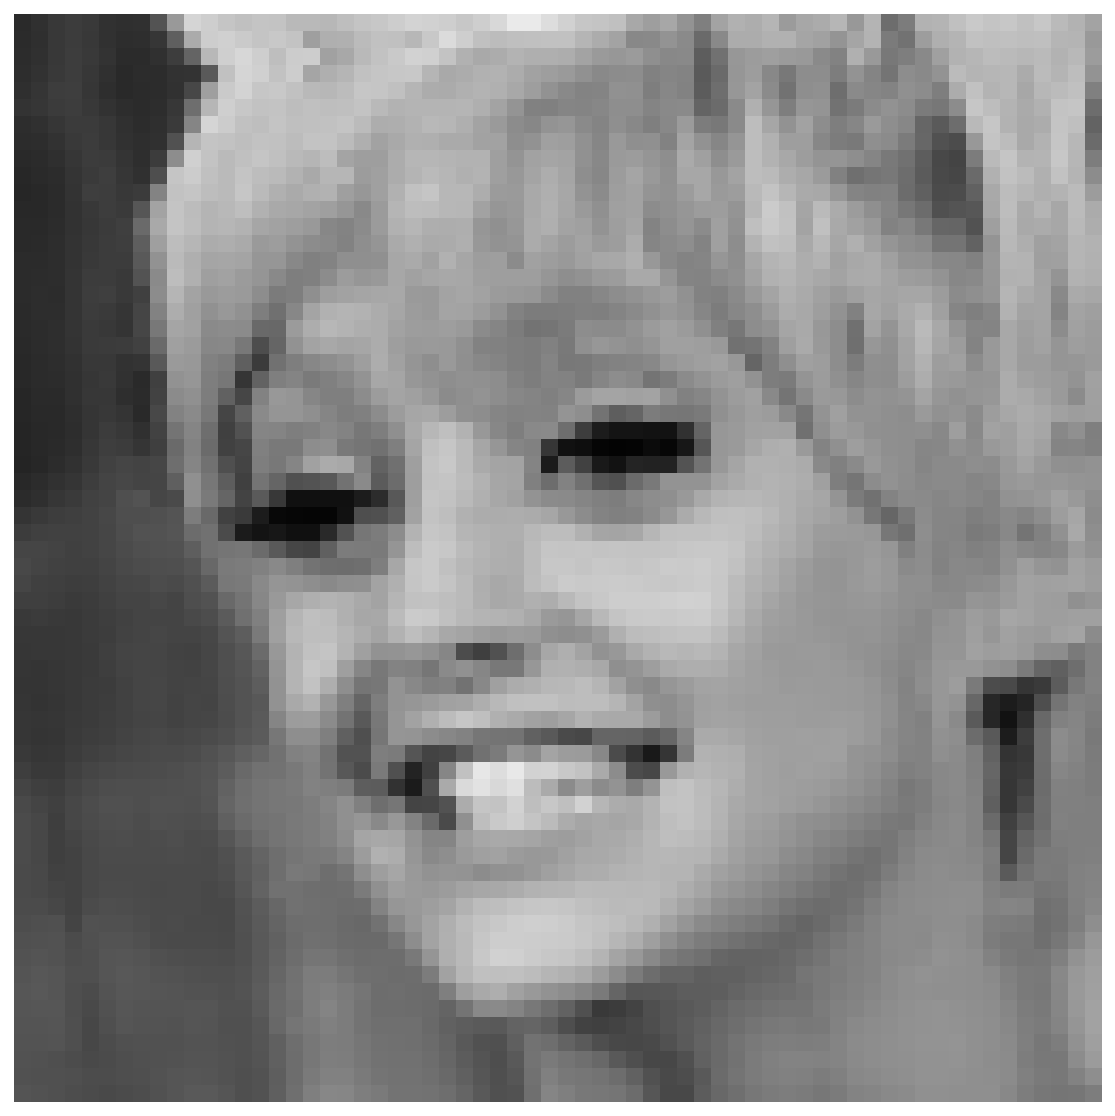

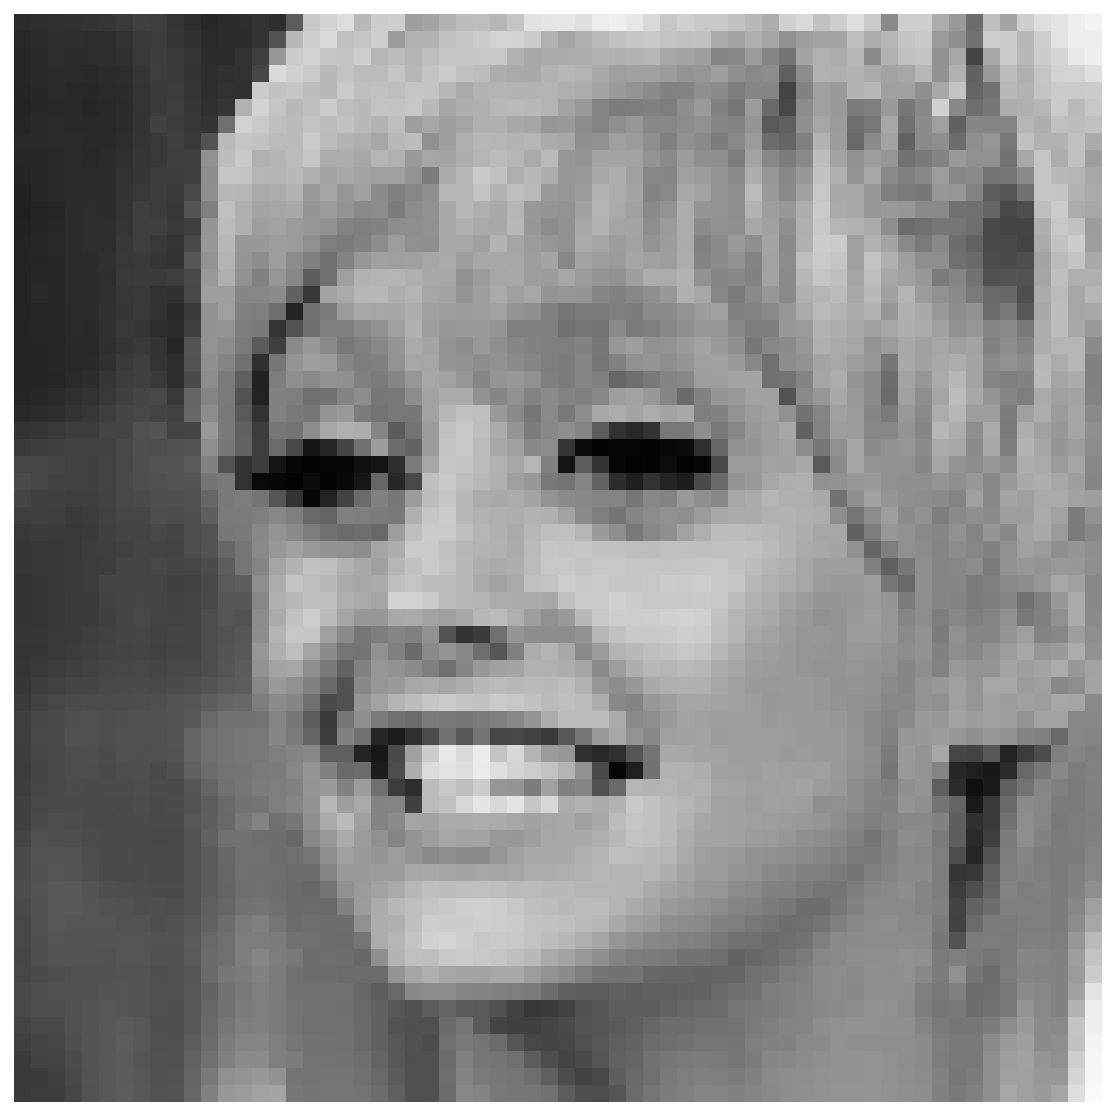

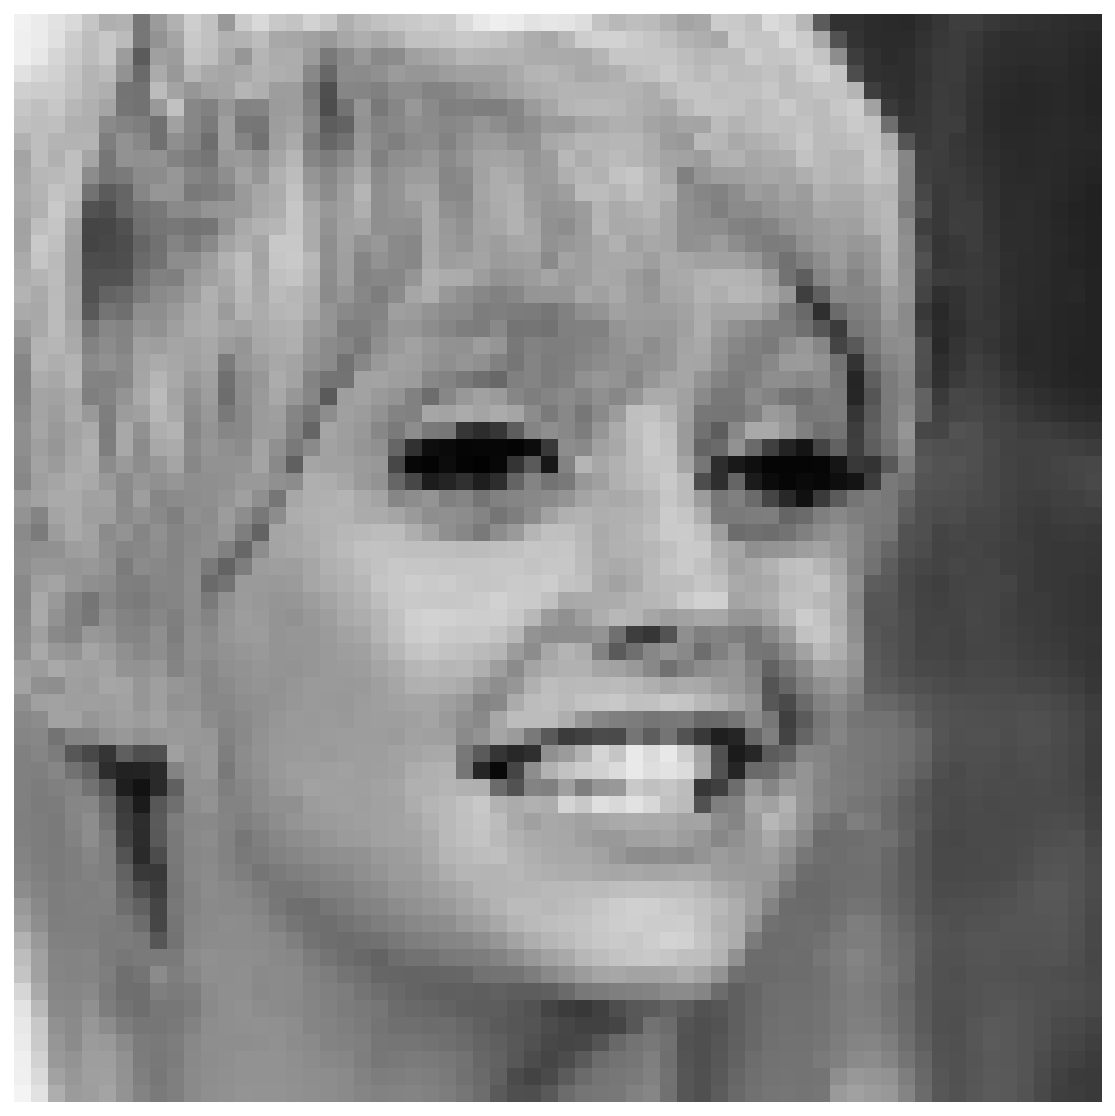

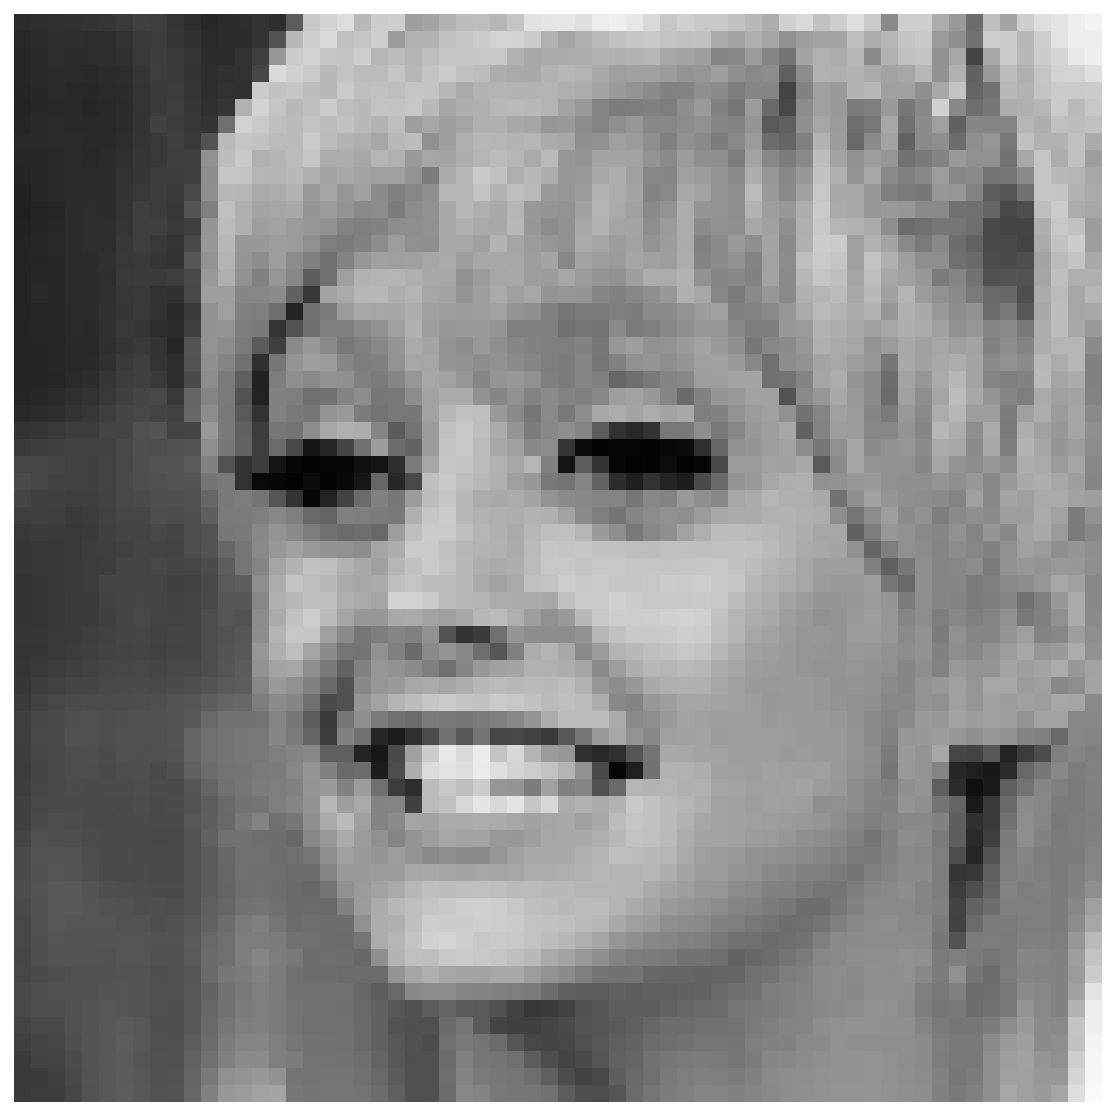

In [ ]:
for i in range(len(image_list)):
  print(i)
  visualize(image_list[i])

## a. Import Data



In [ ]:
### --- From Google Drive --- ###

#from google.colab import drive
#drive.mount('/content/gdrive')

In [ ]:
# give appropriate location

directoryAgeDB = 'AgeDB/'

directoryUTK = 'UTKFace/'

In [ ]:
inside1 = os.listdir(directoryAgeDB)
inside2 = os.listdir(directoryUTK)

print("AgeDB:")
for i in range(10):
    print(inside1[i])

print()

print("UTKface: ")
for i in range(10):
    print(inside2[i])

AgeDB:
0_MariaCallas_35_f.jpg
10000_GlennClose_62_f.jpg
10001_GoldieHawn_23_f.jpg
10002_GoldieHawn_24_f.jpg
10003_GoldieHawn_24_f.jpg
10004_GoldieHawn_27_f.jpg
10005_GoldieHawn_28_f.jpg
10006_GoldieHawn_29_f.jpg
10007_GoldieHawn_30_f.jpg
10008_GoldieHawn_31_f.jpg

UTKface: 
100_0_0_20170112213500903.jpg.chip.jpg
100_0_0_20170112215240346.jpg.chip.jpg
100_1_0_20170110183726390.jpg.chip.jpg
100_1_0_20170112213001988.jpg.chip.jpg
100_1_0_20170112213303693.jpg.chip.jpg
100_1_0_20170112215032192.jpg.chip.jpg
100_1_0_20170117195420803.jpg.chip.jpg
100_1_0_20170119212053665.jpg.chip.jpg
100_1_2_20170105174847679.jpg.chip.jpg
100_1_2_20170112213615815.jpg.chip.jpg


## b. DataLoader

### * AgeDB

In [ ]:
### --- AgeDB Dataset Class --- ###           {}_{person}_{age}_{gender}.jpg

class AgeDBDataset(Dataset):

## data loading
  def __init__(self, directory, device, transform=None, preload=False, **kwargs):
    self.directory = directory
    self.transform = transform
    self.preload = preload
    self.device = device
    self.labels = []
    self.images = []
    
    gender_to_class_id = {
                          'm': 0,
                          'f': 1
    }

    for i, file in enumerate(sorted(os.listdir(self.directory))):
      file_labels = parse('{}_{person}_{age}_{gender}.jpg', file)

      if file_labels is None:
        continue

      if self.preload:
##### fix preload        
        image = Image.open(os.path.join(self.directory, file)).convert('RGB')
        
        if self.transform is not None:
          image = self.transform(image).to(self.device)

      else:
        image = Image.open(os.path.join(self.directory, file)).convert('RGB')

      
      
########
      cropper = Cropper()
      self.images.append(image)
      try: 
        #Get a Numpy array of the cropped image
        cropped_array = cropper.crop(image)
        #Save the cropped image with PIL
        image = Image.fromarray(cropped_array)
        
      except:
        pass
    
      gender = gender_to_class_id[file_labels['gender']]
      person = str(file_labels['person'])
      age = int(file_labels['age'])
      self.labels.append({
                          'person': person,
                          'age': age, 
                          'gender': gender
      })
      
      image = np.array(image)
      for i in range(2):
        augmented_images = self.transform(image=image)['image']
        self.images.append(augmented_images)
########
        gender = gender_to_class_id[file_labels['gender']]
        person = str(file_labels['person'])
        age = int(file_labels['age'])
        self.labels.append({
                            'person': person,
                            'age': age, 
                            'gender': gender
        })

## len(dataset)
  def __len__(self):
    return len(self.labels)

## dataset[0]
  def __getitem__(self, index):
    if torch.is_tensor(index):
      index = index.tolist()

    image = self.images[index]

    if not self.preload:
      #image = Image.open(image).convert('RGB')
      
      if self.transform is not None:
        trans = transforms.Compose([transforms.ToTensor()])
        image = trans(image).to(self.device)

    labels = {
             'person': self.labels[index]['person'], 
             'age': self.labels[index]['age'], 
             'gender': self.labels[index]['gender']
    }

    return image.to(self.device), labels

## DataLoaders - train, validate, test
  def get_loaders(self, batch_size, train_size, test_size, random_seed, **kwargs):
    train_len = int(len(self) * train_size)
    test_len = int(len(self) * test_size)
    validate_len = len(self) - (train_len + test_len)

    self.trainDataset, self.validateDataset, self.testDataset = torch.utils.data.random_split(
      dataset = self, 
      lengths = [train_len, validate_len, test_len],
      generator = torch.Generator().manual_seed(random_seed)
    )

    train_loader = DataLoader(self.trainDataset, batch_size=batch_size)
    validate_loader = DataLoader(self.validateDataset, batch_size=batch_size)
    test_loader = DataLoader(self.testDataset, batch_size=batch_size)

    return train_loader, validate_loader, test_loader


### * UTKFace

In [ ]:
### --- UTKFace Dataset Class --- ###        [age]_[gender]_[race]_[date&time].jpg     1_0_0_20161219140623097.jpg.chip.jpg 

class UTKFaceDataset(Dataset):

## data loading
  def __init__(self, directory, device, transform=None, preload=False, **kwargs):
    self.directory = directory
    self.transform = transform
    self.preload = preload
    self.device = device
    self.labels = []
    self.images = []
    gender_to_class_id = {
                          '0': 0,
                          '1': 1
    }    
    cropper = Cropper()

    for i, file in enumerate(sorted(os.listdir(self.directory))):
      file_labels = parse('{age}_{gender}_{}_{}.jpg.chip.jpg', file)

      if file_labels is None:
        continue

      if self.preload:
        #image = Image.open(os.path.join(self.directory, file)).convert('RGB')
        
        try:
         #Get a Numpy array of the cropped image
          cropped_array = cropper.crop(image)

         #Save the cropped image with PIL
          image = Image.fromarray(cropped_array)

        except:
          pass      
        
        if self.transform is not None:
          image = self.transform(image).to(self.device)

      else:
        image = os.path.join(self.directory, file)

########
      image = Image.open(os.path.join(self.directory, file)).convert('RGB')
      self.images = [image]
      image = np.array(image)
      for i in range(5):
        augmentations = self.transform(image=image)
        augmented_images = augmentations['image']
        self.images.append(augmented_images)
###########


      
      
        gender = gender_to_class_id[file_labels['gender']]
        age = int(file_labels['age'])
        self.labels.append({
                            'age': age, 
                            'gender': gender
          })

## dataset[0]
  def __getitem__(self, index):
    if torch.is_tensor(index):
      index = index.tolist()

    image = self.images[index]

    if not self.preload:
      #image = Image.open(image).convert('RGB')

      try:
       #Get a Numpy array of the cropped image
        cropped_array = cropper.crop(image)

       #Save the cropped image with PIL
        image = Image.fromarray(cropped_array)

      except:
        pass      

      if self.transform is not None:
        trans = transforms.Compose([transforms.ToTensor()])
        image = self.transform(image).to(self.device)

    labels = {'age': self.labels[index]['age'], 
             'gender': self.labels[index]['gender']
      }

    return image.to(self.device), labels

## len(dataset)
  def __len__(self):
    return len(self.labels)

## DataLoaders - train, validate, test
  def get_loaders(self, batch_size, train_size, test_size, random_seed, **kwargs):
    train_len = int(len(self) * train_size)
    test_len = int(len(self) * test_size)
    validate_len = len(self) - (train_len + test_len)

    self.trainDataset, self.validateDataset, self.testDataset = torch.utils.data.random_split(
      dataset = self,
      lengths = [train_len, validate_len, test_len],
      generator = torch.Generator().manual_seed(random_seed)
    )

    train_loader = DataLoader(self.trainDataset, batch_size=batch_size)
    validate_loader = DataLoader(self.validateDataset, batch_size=batch_size)
    test_loader = DataLoader(self.testDataset, batch_size=batch_size)
    
    return train_loader, validate_loader, test_loader


## Dataset Assigned

In [ ]:
#### --- For AgeDB Dataset --- ###

datasetAgeDB = AgeDBDataset(directory = directoryAgeDB,
                       device = device,
                       transform = transformA                       
)

In [ ]:
### --- For UTKFace Dataset --- ###

datasetUTKface = UTKFaceDataset(directory = directoryUTK,
                         device = device,
                         transform = transformA
)

KeyboardInterrupt: ignored

## e. Data Splitting 

In [ ]:
train_loader, validation_loader, test_loader = datasetAgeDB.get_loaders(
    batch_size = batch_size,
    train_size = 0.7,
    test_size = 0.2,
    random_seed = 42
)

In [ ]:
train_set, validation_set, test_set = datasetUTKface.get_loaders(
    batch_size = batch_size,
    train_size = 0.7,
    test_size = 0.2,
    random_seed = 50
)

## e. EDA - Exploratory Data Analysis

In [ ]:
print(len(datasetAgeDB))
#print(len(datasetUTKface))

49464


In [ ]:
print(datasetAgeDB[49463])
print()
#print(datasetUTKface[0])

(tensor([[[0.0784, 0.0784, 0.0784,  ..., 0.1294, 0.1255, 0.1294],
         [0.0824, 0.0824, 0.0745,  ..., 0.1255, 0.1176, 0.1176],
         [0.0863, 0.0824, 0.0745,  ..., 0.1176, 0.1137, 0.1098],
         ...,
         [0.4431, 0.3804, 0.3373,  ..., 0.3020, 0.2588, 0.2431],
         [0.4627, 0.3843, 0.3569,  ..., 0.2353, 0.2392, 0.2314],
         [0.4745, 0.3882, 0.3686,  ..., 0.2000, 0.2392, 0.2353]],

        [[0.0784, 0.0784, 0.0784,  ..., 0.1294, 0.1255, 0.1294],
         [0.0824, 0.0824, 0.0745,  ..., 0.1255, 0.1176, 0.1176],
         [0.0863, 0.0824, 0.0745,  ..., 0.1176, 0.1137, 0.1098],
         ...,
         [0.4431, 0.3804, 0.3373,  ..., 0.3020, 0.2588, 0.2431],
         [0.4627, 0.3843, 0.3569,  ..., 0.2353, 0.2392, 0.2314],
         [0.4745, 0.3882, 0.3686,  ..., 0.2000, 0.2392, 0.2353]],

        [[0.0784, 0.0784, 0.0784,  ..., 0.1294, 0.1255, 0.1294],
         [0.0824, 0.0824, 0.0745,  ..., 0.1255, 0.1176, 0.1176],
         [0.0863, 0.0824, 0.0745,  ..., 0.1176, 0.1137, 0

In [ ]:
datasetAgeDB[0][0][0][0][0]

tensor(0.4275, device='cuda:0')

In [ ]:
type(datasetAgeDB[0])

tuple

In [ ]:
datasetAgeDB.labels[0]

{'person': 'MariaCallas', 'age': 35, 'gender': 1}

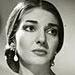

In [ ]:
datasetAgeDB.images[0]

In [ ]:
plt.figure()
plt.imshow(plt.imread(dataset.images[0]))

In [ ]:
print(dataset.labels[1])
print(dataset.images[1])

plt.figure()
plt.imshow(plt.imread(dataset.images[1]))

In [ ]:
plt.figure()
image = Image.open(dataset.images[48])
plt.imshow((image))
print(image.height, image.width)
image = image.resize(
    size = (400,400),
    resample=Image.LANCZOS,
)
plt.figure()
image = image.convert('LA')
plt.imshow(image)
print(image.height, image.width)

In [ ]:
age = []
gender = []
for i in range(len(dataset)):
    age.append(dataset.labels[i]['age'])
    gender.append(dataset.labels[i]['gender'])

In [ ]:
listofzeros = [0] * len(dataset)
same_age = [i for i in range(min(age), max(age) + 1)]

age_number = dict(zip(same_age, listofzeros))
copy_age = age_number.copy()
age_number

In [ ]:
for i in range(len(dataset)):
    if dataset.labels[i]['age'] in age_number:
        age_number[dataset.labels[i]['age']] += 1
    
age_number

## f. Data Visualization

# 2. Model

In [ ]:
class AngularPenaltySMLoss(nn.Module):

    def __init__(self, in_features, out_features, loss_type='arcface', eps=1e-7, s=None, m=None):
        '''
        Angular Penalty Softmax Loss
        Three 'loss_types' available: ['arcface', 'sphereface', 'cosface']
        These losses are described in the following papers: 
        
        ArcFace: https://arxiv.org/abs/1801.07698
        SphereFace: https://arxiv.org/abs/1704.08063
        CosFace/Ad Margin: https://arxiv.org/abs/1801.05599
        '''
        super(AngularPenaltySMLoss, self).__init__()
        loss_type = loss_type.lower()
        
        assert loss_type in  ['arcface', 'sphereface', 'cosface']
        
        if loss_type == 'arcface':
            self.s = 64.0 if not s else s
            self.m = 0.5 if not m else m
        if loss_type == 'sphereface':
            self.s = 64.0 if not s else s
            self.m = 1.35 if not m else m
        if loss_type == 'cosface':
            self.s = 30.0 if not s else s
            self.m = 0.4 if not m else m
            
        self.loss_type = loss_type
        self.in_features = in_features
        self.out_features = out_features
        self.fc = nn.Linear(in_features, out_features, bias=False).cuda()
        self.eps = eps

    def forward(self, x, labels):
        '''
        input shape (N, in_features)
        '''
        assert len(x) == len(labels)
        assert torch.min(labels) >= 0
        assert torch.max(labels) < self.out_features
        
        for W in self.fc.parameters():
            W = F.normalize(W, p=2, dim=1)

        x = F.normalize(x, p=2, dim=1)

        wf = self.fc(x)
        
        if self.loss_type == 'cosface':
            numerator = self.s * (torch.diagonal(wf.transpose(0, 1)[labels]) - self.m)
        if self.loss_type == 'arcface':
            numerator = self.s * torch.cos(torch.acos(torch.clamp(torch.diagonal(wf.transpose(0, 1)[labels]), -1.+self.eps, 1-self.eps)) + self.m)
        if self.loss_type == 'sphereface':
            numerator = self.s * torch.cos(self.m * torch.acos(torch.clamp(torch.diagonal(wf.transpose(0, 1)[labels]), -1.+self.eps, 1-self.eps)))

        excl = torch.cat([torch.cat((wf[i, :y], wf[i, y+1:])).unsqueeze(0) for i, y in enumerate(labels)], dim=0)
        denominator = torch.exp(numerator) + torch.sum(torch.exp(self.s * excl), dim=1)
        L = numerator - torch.log(denominator)
        return -torch.mean(L)

In [ ]:
class ConvBaseline(nn.Module):
    def __init__(self, num_classes=117):
        super(ConvBaseline, self).__init__()
        self.convlayers = ConvNet()
        self.fc_final = nn.Linear(117, num_classes)

    def forward(self, x, embed=False):
        x = self.convlayers(x)
        if embed:
            return x
        x = self.fc_final(x)
        return x

In [ ]:
class ConvAngularPen(nn.Module):
    def __init__(self, num_classes=117, loss_type='arcface'):
        super(ConvAngularPen, self).__init__()
        self.convlayers = ConvNet()
        self.adms_loss = AngularPenaltySMLoss(117, num_classes, loss_type=loss_type)

    def forward(self, x, labels=None, embed=False):
        x = self.convlayers(x)
        if embed:
            return x
        L = self.adms_loss(x, labels)
        return L

In [ ]:
class ConvNet(nn.Module):

    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 10, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(10))
        self.layer2 = nn.Sequential(
            nn.Conv2d(10, 15, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.BatchNorm2d(15))
        self.layer3 = nn.Sequential(
            nn.Conv2d(15, 20, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(20),
            nn.MaxPool2d(kernel_size=2, stride=2))
        
        self.fc_projection = nn.Linear(18000, 117)

    def forward(self, x, embed=False):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc_projection(x)
        return x

## a. LinearNN

In [ ]:
class LinearRegression(nn.Module):
  def __init__(self, input_size, hidden_units, num_classes):
    super(LinearRegression, self).__init__()
    self.input = nn.Linear(input_size, hidden_units)
    self.LeakyReLU = nn.LeakyReLU()
    self.output = nn.Linear(hidden_units, num_classes)

  def forward(self, x):
    out = self.input(x)
    out = self.LeakyReLU(out)
    out = self.output(out)
    out = out.reshape(out.size(0), -1) #add

    return out

## b. CNN

In [ ]:
# input_channel = 1
# output_channel = 6
# kernel_size = 5
# torch.Size([64, 1, 28, 28])

#class CNN(nn.Module):
#    def __init__(self):
#        super(CNN, self).__init__()
#        self.conv1 = nn.Conv2d(1, 1, 2)
#        self.pool = nn.MaxPool2d(2, 1)
#        self.conv2 = nn.Conv2d(1, 2, 2)
#        self.pool = nn.MaxPool2d(2, 1)
#        self.conv3 = nn.Conv2d(2, 3, 2)
#        self.pool = nn.MaxPool2d(2, 1)
#        self.conv4 = nn.Conv2d(3, 4, 2)
#        self.pool = nn.MaxPool2d(2, 2)
#        self.conv5 = nn.Conv2d(4, 5, 2)
#        
#        self.fc1 = nn.Linear(5*8*8, 202)
#        self.fc2 = nn.Linear(202, 151)
#        self.fc3 = nn.Linear(151, 101)
#
#    def forward(self, x):
#        # -> n, 1, 32, 32
#        x = self.pool(F.relu(self.conv1(x)))
#        x = self.pool(F.relu(self.conv2(x)))
#        x = self.pool(F.relu(self.conv3(x)))
#        x = self.pool(F.relu(self.conv4(x)))
#        x = self.pool(F.relu(self.conv5(x)))
#        x = x.view(x.size(0), 5*8*8)
#        x = F.relu(self.fc1(x))
#        x = F.relu(self.fc2(x))
#        x = self.fc3(x)
#        
#        return x

In [ ]:
class Unit(nn.Module):
    def __init__(self,in_channels, out_channels):
        super(Unit,self).__init__()
        
        self.conv = nn.Conv2d(in_channels = in_channels,
                              kernel_size = 3,
                              out_channels = out_channels,
                              stride = 1,
                              padding = 1)
        
        self.bn = nn.BatchNorm2d(num_features = out_channels)
        self.relu = nn.LeakyReLU()

    def forward(self,input):
        output = self.conv(input)
        output = self.bn(output)
        output = self.relu(output)

        return output

In [ ]:
class CNN(nn.Module):                                     #####gradient reversal layer
    def __init__(self, num_classes = 116+1):
        super(CNN, self).__init__()
        
        
        self.unit1 = Unit(in_channels = 3, out_channels = 5)
        self.pool1 = nn.MaxPool2d(kernel_size = 2)
        self.unit2 = Unit(in_channels = 5, out_channels = 10)
        self.unit3 = Unit(in_channels = 10, out_channels = 15)
        self.pool2 = nn.MaxPool2d(kernel_size = 2)
        self.unit4 = Unit(in_channels = 15, out_channels = 20)
        self.unit5 = Unit(in_channels = 20, out_channels = 25)
        self.pool3 = nn.MaxPool2d(kernel_size = 2)
        self.unit6 = Unit(in_channels = 25, out_channels = 30)
        self.unit7 = Unit(in_channels = 30, out_channels = 35)
        self.avgpool = nn.AvgPool2d(kernel_size = 3)
        
        
        self.net = nn.Sequential(self.unit1,
                                 self.pool1, 
                                 self.unit2, 
                                 self.unit3, 
                                 self.pool2,
                                 self.unit4, 
                                 self.unit5,
                                 self.pool3,
                                 self.unit6, 
                                 self.unit7,
                                 self.avgpool)
        
        self.fc1 = nn.Sequential(nn.Linear(in_features = 140, out_features = 125),
                                 nn.LeakyReLU(),
                                 nn.Dropout(0.3),
                                 nn.Linear(in_features = 125, out_features = num_classes))

    def forward(self, input):
        output = self.net(input)
        output = output.view(-1, 140)
        output = self.fc1(output)
        return output

## c. RNN

In [ ]:
print("train - ", len(train_loader)*0.7, len(train_loader),
      " val - ", len(datasetAgeDB)*0.2, len(validation_loader),
      " test - ", len(datasetAgeDB)*0.1, len(test_loader))

train -  34624.799999999996 541  val -  9892.800000000001 78  test -  4946.400000000001 155


In [ ]:
sum = len(train_loader) + len(validation_loader) + len(test_loader)
print(sum, len(datasetAgeDB))
sum == len(datasetAgeDB)

774 49464


False

In [ ]:
# plot image
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [ ]:
def findAge(t_loader):
  listofzeros = [0] * len(dataset)
  same_age = [i for i in range(min(age), max(age) + 1)]
  age_number = dict(zip(same_age, listofzeros))
  sum = 0
  
  for i, (imgs, labels) in enumerate(t_loader):
  
    X_train_images = imgs.to(device)
    y_train_ages = labels['age'].to(device)
  
    for i in range(len(y_train_ages)):
      if y_train_ages[i].item() in age_number:
        age_number[y_train_ages[i].item()] += 1
        sum += 1

  print(sum)
  print(i)
  return age_number

# images.shape
# print(y_train_ages.item())
#
# if i == 5:
#   break
#

In [ ]:
# get some random training images
#saaa = 0
#for i, (imgs, labels) in enumerate(train_loader):
# 
#  X_train_images = imgs.to(device)
#  y_train_ages = labels['age'].to(device)
#  # show images
#  
#  print(len(y_train_ages), y_train_ages)
#  
#  saaa = saaa + len(y_train_ages)
#
#
#print(i)
#print(saaa)
#

In [ ]:
def plotTTage(train, test):  
  #plot 1:
  train_age = findAge(train).items()
  x1, y1 = zip(*train_age)
  
  #plot 2:
  test_age = findAge(test).items()
  x2, y2 = zip(*test_age)
  
  plt.plot(x1, y1)
  plt.plot(x2, y2)
  
  plt.legend(["Train", "Test"])
  
  plt.title("Data Distribution")
  plt.xlabel("Age")
  plt.ylabel("Number of Images")
  
  plt.grid()
  
  plt.show()

In [ ]:
plotTTage(train_loader, test_loader)

In [ ]:
plotTTage(train_set, test_set)

In [ ]:
findAge(train_loader)

In [ ]:
findAge(test_loader)

In [ ]:
findAge(train_set)

In [ ]:
findAge(test_set)

## c. Using Model

In [ ]:
# model = LinearRegression(input_size = input_size,
#                          hidden_units = hidden_units,
#                          num_classes = num_classes).to(device)

In [ ]:
model = CNN().to(device)

In [ ]:
#model =  ConvAngularPen(loss_type='arcface').to(device)

In [ ]:
#model = ConvNet().to(device)

In [ ]:
#model = ConvBaseline().to(device)

In [ ]:
model

CNN(
  (unit1): Unit(
    (conv): Conv2d(3, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): LeakyReLU(negative_slope=0.01)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (unit2): Unit(
    (conv): Conv2d(5, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): LeakyReLU(negative_slope=0.01)
  )
  (unit3): Unit(
    (conv): Conv2d(10, 15, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(15, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): LeakyReLU(negative_slope=0.01)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (unit4): Unit(
    (conv): Conv2d(15, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(20, eps=1e-05,

# 3. Loss function and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

# Dont use softmax with cross entropy loss

# 4. Training Testing

In [ ]:
#torch.cuda.empty_cache()

## a. Training Loop

In [ ]:
lab = [i for i in range(116+1)]

In [ ]:
### --- Angular Sanity Check --- ###

def trainAngularSanity(model, optimizer, train_loader, num_epochs):
  imgs, labels = next(iter(train_loader))
  step_size = len(train_loader)
  lab = [i for i in range(116+1)]
  for epoch in range(num_epochs):
      
    X_train_images = imgs.to(device)
    y_train_ages = labels['age'].to(device)
  #  print(labels['age'])
  # y_train_gender = torch.as_tensor(labels['gender']).to(device)

  # Forward Pass and Loss
  # target = torch.randn(3).sign()
  # loss = criterion(y_predicted_output_scores, y_train_ages, target)
    loss = model(X_train_images, y_train_ages)
  # loss = criterion(y_predicted_output_scores, y_train_gender)

  
    
  # Zeros Gradients
    optimizer.zero_grad()

  # Backward Pass
    loss.backward()

  # Update Weights
    optimizer.step()

  # if (epoch+1) % 10 == 0:
  # if (i+1) % step_size == 0:
     
    if i % 10 == 0:
      clear_output()
    print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')

  print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')
  return model.cpu()


In [ ]:
### --- Sanity Check --- ###

def trainSanity(model, criterion, optimizer, train_loader, num_epochs):
  imgs, labels = next(iter(train_loader))
  step_size = len(train_loader)
  lab = [i for i in range(116+1)]
  for epoch in range(num_epochs):
      
    X_train_images = imgs.to(device)
    y_train_ages = labels['age'].to(device)
  #  print(labels['age'])
  # y_train_gender = torch.as_tensor(labels['gender']).to(device)

  # Forward Pass and Loss
    y_predicted_output_scores = model(X_train_images)
  # target = torch.randn(3).sign()
  # loss = criterion(y_predicted_output_scores, y_train_ages, target)
    loss = criterion(y_predicted_output_scores, y_train_ages)
  # loss = criterion(y_predicted_output_scores, y_train_gender)

  
    
  # Zeros Gradients
    optimizer.zero_grad()

  # Backward Pass
    loss.backward()

  # Update Weights
    optimizer.step()

  # if (epoch+1) % 10 == 0:
  # if (i+1) % step_size == 0:
     
    if i % 10 == 0:
      clear_output()
    print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')

  print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')


In [ ]:
### --- JUST DO IT --- ###

def train(model, criterion, optimizer, train_loader, num_epochs):

  step_size = len(train_loader)
  for epoch in range(num_epochs):
    
    for i, (imgs, labels) in enumerate(train_loader):
      
      X_train_images = imgs.to(device)
      y_train_ages = labels['age'].to(device)
    #  print(labels['age'])
    # y_train_gender = torch.as_tensor(labels['gender']).to(device)

    # Forward Pass and Loss
      y_predicted_output_scores = model(X_train_images)
    # target = torch.randn(3).sign()
    # loss = criterion(y_predicted_output_scores, y_train_ages, target)
      loss = criterion(y_predicted_output_scores, y_train_ages)
    # loss = criterion(y_predicted_output_scores, y_train_gender)

    # Zeros Gradients
      optimizer.zero_grad()

    # Backward Pass
      loss.backward()

    # Update Weights
      optimizer.step()

    # if (epoch+1) % 10 == 0:
    # if (i+1) % step_size == 0:
     
      if i % 10 == 0:
        clear_output()
      print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')

  print(f'EPOCH: {epoch+1}/{num_epochs}, STEP: {i+1}/{step_size}, LOSS: {loss.item():.4f}')



In [ ]:
train(model, criterion, optimizer, train_loader, num_epochs)

In [ ]:
trainSanity(model, criterion, optimizer, train_loader, num_epochs)

RuntimeError: ignored

In [ ]:
#model = trainAngularSanity(model, optimizer, train_loader, num_epochs)

In [ ]:
## plot
#predicted = model(x).detach().numpy()
#plt.plot(X_numpy, y_numpy, 'ro')
#plt.plot(X_numpy, predicted, 'b')
#plt.show()

## b. Evaluate

In [ ]:
def angularEval(model, test_loader):
  model.to(device).eval()

  with torch.no_grad():
    correct = 0
    total = 0

    for imgs, labels in tqdm(test_loader):

      X_test_images = imgs.to(device)
      y_test_ages = labels['age'].to(device)
    # y_test_genders = torch.as_tensor(labels['gender']).to(device)
      
      y_predicted_output_scores = model(X_test_images)
    # labels = labels.to(device)

    # y_predicted_classes = y_predicted_output_scores.round()
    # accuracy = y_predicted_classes.eq.(y_test_ages).sum() / float.(y_test_ages.shape[0])
    # accuracy = y_predicted_classes.eq.(y_test_genders).sum() / float.(y_test_genders.shape[0])

      _, predicted = torch.max(y_predicted_output_scores, 1)

      total += y_test_ages.size(0)
      correct += (predicted == y_test_ages).sum().item()

    # total += y_test_genders.size(0)
    # correct += (predicted == y_test_genders).sum().item()

    # print(y_predicted_output_scores)
  model.train()        # turn back training mode on after eval step
  print('\n')
  print(f"Accuracy: {(100 * correct) / total :.4f}%")
  print("Correct: ", correct, " Total:", total)

In [ ]:
def eval(model, test_loader):
  model.to(device).eval()

  with torch.no_grad():
    correct = 0
    total = 0

    for imgs, labels in tqdm(test_loader):

      X_test_images = imgs.to(device)
      y_test_ages = labels['age'].to(device)
    # y_test_genders = torch.as_tensor(labels['gender']).to(device)
      
      y_predicted_output_scores = model(X_test_images)
    # labels = labels.to(device)

    # y_predicted_classes = y_predicted_output_scores.round()
    # accuracy = y_predicted_classes.eq.(y_test_ages).sum() / float.(y_test_ages.shape[0])
    # accuracy = y_predicted_classes.eq.(y_test_genders).sum() / float.(y_test_genders.shape[0])

      _, predicted = torch.max(y_predicted_output_scores, 1)

      total += y_test_ages.size(0)
      correct += (predicted == y_test_ages).sum().item()

    # total += y_test_genders.size(0)
    # correct += (predicted == y_test_genders).sum().item()

    # print(y_predicted_output_scores)
  model.train()        # turn back training mode on after eval step
  print('\n')
  print(f"Accuracy: {(100 * correct) / total :.4f}%")
  print("Correct: ", correct, " Total:", total)

In [ ]:
#def get_embeds(model, loader):
#    model = model.to(device).eval()
#    full_embeds = []
#    full_labels = []
#    with torch.no_grad():
#        for i, (feats, labels) in enumerate(loader):
#            feats = feats[:100].to(device)
#            full_labels.append(labels[:100].cpu().detach().numpy())
#            embeds = model(feats, embed=True)
#            full_embeds.append(F.normalize(embeds.detach().cpu()).numpy())
#    model = model.cpu()
#    return np.concatenate(full_embeds), np.concatenate(full_labels)

In [ ]:
# loss_types = ['cosface', 'sphereface', 'arcface']
#    for loss_type in loss_types:
#        print('Training {} model....'.format(loss_type))
#        model_am = train_am(train_loader, loss_type)
#        am_embeds, am_labels = get_embeds(model_am, example_loader)
#        plot(am_embeds, am_labels, fig_path='./figs/{}.png'.format(loss_type))
#        print('Saved {} figure'.format(loss_type))
#        del model_am, am_embeds, am_labels

## c. Results

In [ ]:
### --- Training Accuracy --- ###

eval(model, train_loader)

#angularEval(model, train_loader)

In [ ]:
### --- Testing Accuracy on AgeDB --- ###

eval(model, test_loader)

#angularEval(model, test_loader)

In [ ]:
### --- Testing Accuracy on AgeDB --- ###

eval(model, test_set)

#angularEval(model, test_set)



---



In [ ]:
PATH = 'F:/CSE465 PROJECT/Age_Estimation'
torch.save(model, os.path.join(PATH, 'CNNmodel.pth'))

# 5. Inferences 

In [ ]:
model = torch.load(os.path.join(PATH, 'CNNmodel.pth'))

In [ ]:
from torch.autograd import Variable

loader = transforms.Compose([transforms.Resize((64, 64)),
                                Grayscale(num_output_channels = 3),
                                transforms.ToTensor()
])

def image_loader(image_name):
    """load image, returns cuda tensor"""
    image = loader(image_name)
    plt.imshow(image.permute(1, 2, 0))
    image = image.float()
    image = Variable(image, requires_grad=False)
    image = image.unsqueeze(0)  #this is for VGG, may not be needed for ResNet
    return image   #assumes that you're using GPU


In [ ]:
from PIL import Image
from autocrop import Cropper

cropper = Cropper()

# Get a Numpy array of the cropped image
cropped_array = cropper.crop('C:/Users/nahid/OneDrive/Pictures/Screenshots/a.jpg')

# Save the cropped image with PIL
cropped_image = Image.fromarray(cropped_array)
#cropped_image.save('cropped.png')
#cropped_image = Image.open('C:/Users/nahid/OneDrive/Pictures/Screenshots/a.jpg') 

In [ ]:
#image = image_loader('C:/Users/nahid/OneDrive/Pictures/Screenshots/a.jpg')
#img1 = imread('C:/Users/nahid/OneDrive/Pictures/b.jpg')

plt.imshow(cropped_image)
image = image_loader(cropped_image)

output = model(image)
age = output.data.cpu().numpy().argmax()
print(age)


In [ ]:
#def predict_image(image):
#
#  image_tensor = transforms(image).float()
#  image_tensor = image_tensor.unsqueeze_(0)
#  input = Variable(image_tensor)
#  input = input.to(device)
#  output = model(input)
#  age = output.data.cpu().numpy().argmax()
#  return age 

In [ ]:
#def get_random_images(num):
#
#  inside = os.listdir(directory)
#  for i in range(10):
#    print(inside[i])
#
#  data = datasets.ImageFolder(directory, transform=transform)
#  classes = data.classes
#  indices = list(range(len(data)))
#  np.random.shuffle(indices)
#  idx = indices[:num]
#  from torch.utils.data.sampler import SubsetRandomSampler
#  sampler = SubsetRandomSampler(idx)
#  loader = torch.utils.data.DataLoader(data, 
#                 sampler=sampler, batch_size=num)
#  dataiter = iter(loader)
#  images, labels = dataiter.next()
#  return images, labels

In [ ]:
#to_pil = transforms.ToPILImage()
#images, labels = get_random_images(5)
#fig=plt.figure(figsize=(10,10))
#
#for ii in range(len(images)):
#
#  image = to_pil(images[ii])
#  index = predict_image(image)
#  sub = fig.add_subplot(1, len(images), ii+1)
#  res = int(labels[ii]) == index
#  sub.set_title(str(classes[index]) + ":" + str(res))
#  plt.axis('off')
#  plt.imshow(image)
#  
#plt.show()